# Fine-tune Nemotron 3 Nano-30B-A3B with TRL SFT (Transformers)

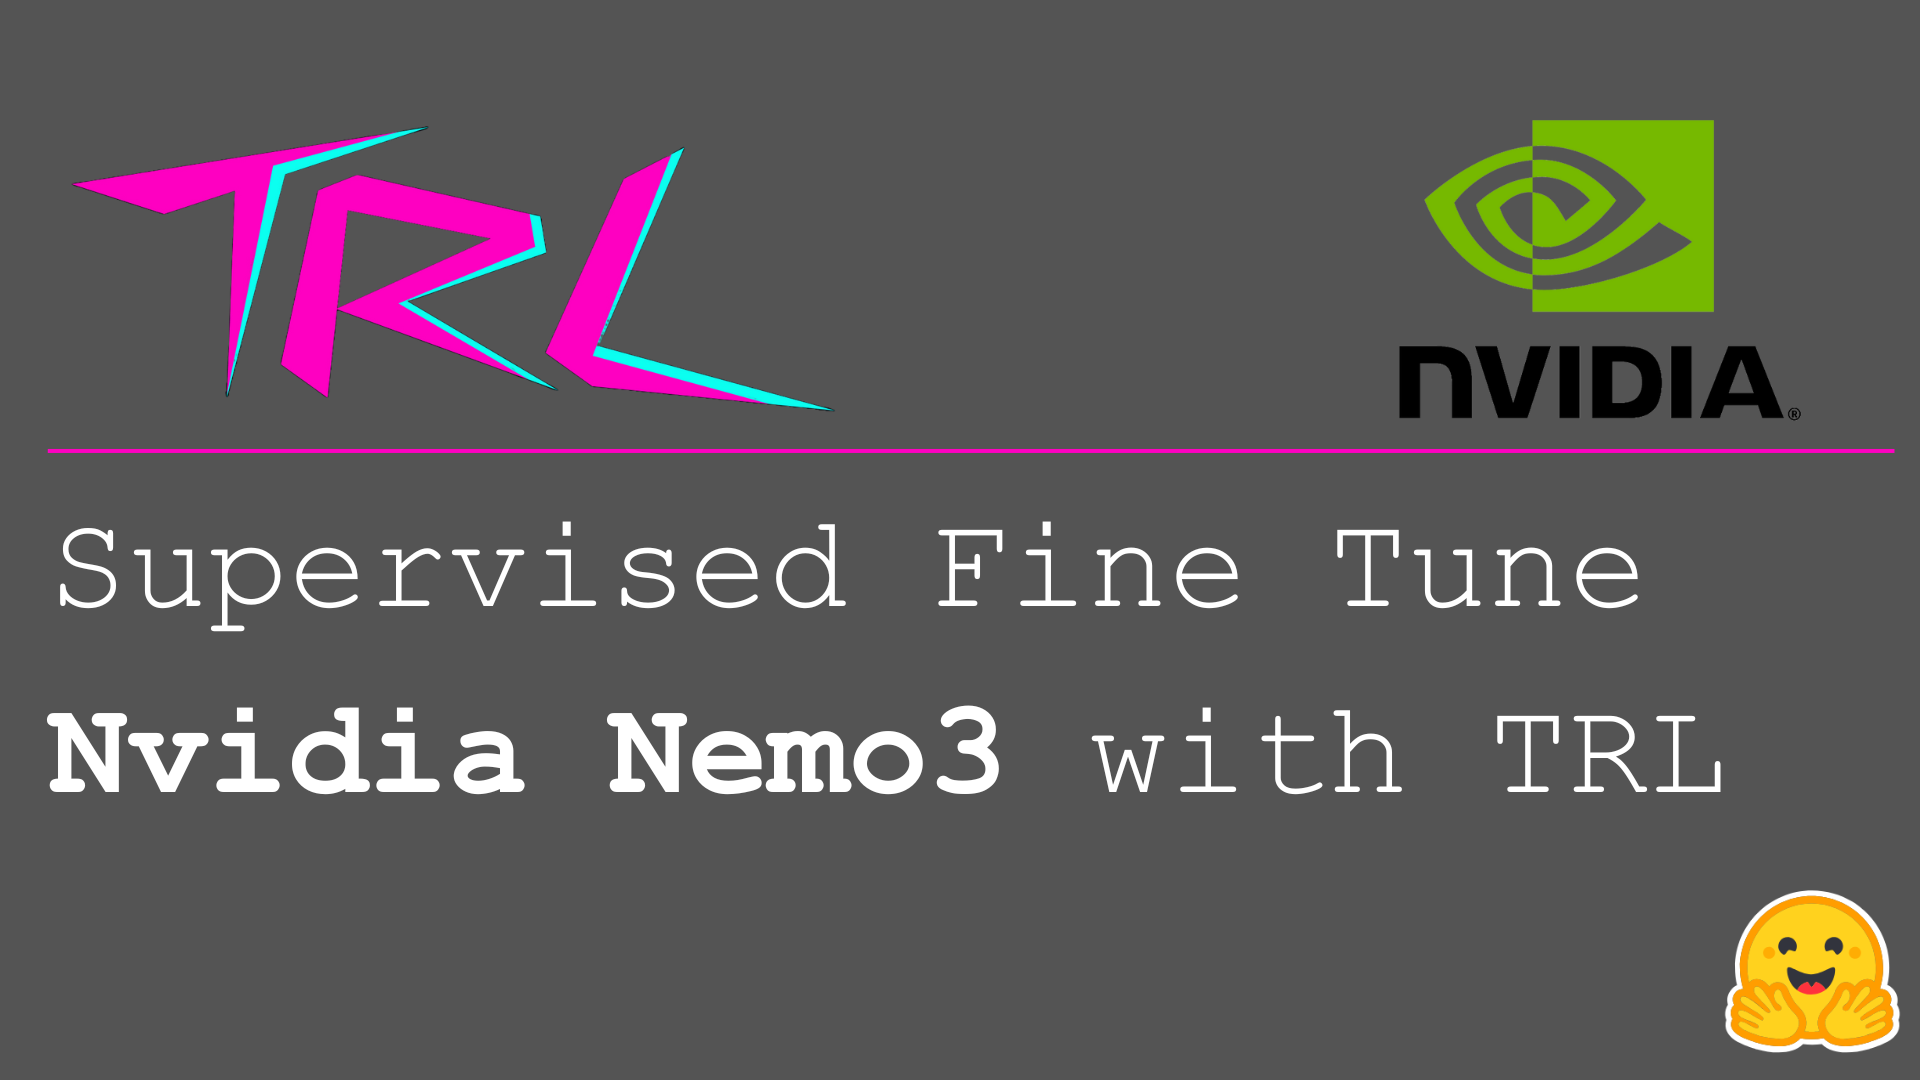

### Installation

In [ ]:
%pip install --upgrade -qqq uv
!uv pip install --upgrade transformers==4.56.2 tokenizers trl==0.22.2 trackio datasets peft

# Mamba Kernels
!uv pip install --no-build-isolation mamba_ssm==2.2.5
!uv pip install --no-build-isolation causal_conv1d==1.5.2


### Load the Model


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "unsloth/Nemotron-3-Nano-30B-A3B"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    attn_implementation="eager",  # Change to Flash Attention if GPU has support
    dtype=torch.float16,  # Change to bfloat16 if GPU has support
    use_cache=True,  # Whether to cache attention outputs to speed up inference
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_id)


We now add LoRA adapters so we only need to update a small amount of parameters!

In [ ]:
from peft import LoraConfig

# You may need to update `target_modules` depending on the architecture of your chosen model.
# For example, different LLMs might have different attention/projection layer names.
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)


<a name="Data"></a>
### Data Prep

This notebook loads `HuggingFaceH4/Multilingual-Thinking` and uses its `messages` field for chat-style SFT.

In the code below we:
- Drop unused columns (`reasoning_language`, `developer`, `user`, `analysis`, `final`).
- Move any per-message `thinking` field into the message `content` under `<think>...</think>` tags.

After that, we render each conversation into a single training string using `tokenizer.apply_chat_template(...)` and store it in `dataset['text']`.

In [ ]:
from datasets import load_dataset

dataset_name = "HuggingFaceH4/Multilingual-Thinking"
dataset = load_dataset(dataset_name, split="train")
dataset = dataset.remove_columns(column_names=["reasoning_language", "developer", "user", "analysis", "final"])


def merge_thinking_and_remove_key(example):
    new_messages = []
    for msg in example["messages"]:
        content = msg["content"]
        thinking = msg.pop("thinking", None)
        if thinking and isinstance(thinking, str) and thinking.strip():
            content = f"<think>\n{thinking}\n</think>\n{content}"
        msg["content"] = content
        new_messages.append(msg)
    example["messages"] = new_messages
    return example


dataset = dataset.map(merge_thinking_and_remove_key)

We now have to apply the chat template for `Nemotron` onto the conversations, and save it to `text`.

In [ ]:
def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False) for convo in convos]
    return {
        "text": texts,
    }


dataset = dataset.map(formatting_prompts_func, batched=True)

Let's see how the chat template did!


In [ ]:
dataset[100]["text"]

'<|im_start|>system\n<|im_end|>\n<|im_start|>user\nOn a wall, there are two clocks with the same shape (radius) and the same speed, but they may not show the same hour. The minimum distance between the edges of their hands is \\( m \\), and the maximum distance is \\( M \\). What is the distance between their centers?<|im_end|>\n<|im_start|>assistant\n<think>\nOkay, so I have this problem here about two clocks on a wall. Both clocks have the same radius and the same speed, but they might show different times. The minimum distance between the edges of their hands is m, and the maximum is M. I need to find the distance between their centers. Hmm, let\'s break this down.\n\nFirst, let me visualize the situation. Both clocks are circular with the same radius, let\'s say radius r. The hands of each clock are moving at the same speed, so their minute and hour hands move at the same rates. However, they might not be showing the same time, which means their hands could be pointing in different

<a name="Train"></a>
### Train the model
Now let's train the model with TRL's `SFTTrainer`. In this notebook the config uses `max_steps=30` for a short run; for a full pass over the dataset, set `num_train_epochs=1` and remove/disable `max_steps`.

In [ ]:
from trl import SFTConfig

output_dir = "nemo3-sft-bnb"

training_args = SFTConfig(
    # Training schedule / optimization
    per_device_train_batch_size=1,  # Batch size per GPU
    gradient_accumulation_steps=4,  # Gradients are accumulated over multiple steps → effective batch size = 2 * 8 = 16
    warmup_steps=5,
    # num_train_epochs = 1,               # Number of full dataset passes. For shorter training, use `max_steps` instead (this case)
    max_steps=30,
    learning_rate=2e-4,  # Learning rate for the optimizer
    optim="paged_adamw_8bit",  # Optimizer
    # Logging / reporting
    logging_steps=1,  # Log training metrics every N steps
    report_to="trackio",  # Experiment tracking tool
    output_dir=output_dir,  # Where to save model checkpoints and logs
    max_length=128,  # Maximum input sequence length
    activation_offloading=True,  # Offload activations to CPU to reduce GPU memory usage
    gradient_checkpointing=True,  # Save memory by re-computing activations during backpropagation
    # Hub integration
    push_to_hub=True,  # Automatically push the trained model to the Hugging Face Hub
    # The model will be saved under your Hub account in the repository named `output_dir`
    gradient_checkpointing_kwargs={"use_reentrant": False},  # To prevent warning message
)


from trl import SFTTrainer

trainer = SFTTrainer(model=model, args=training_args, train_dataset=dataset, peft_config=peft_config)

The repository unsloth/Nemotron-3-Nano-30B-A3B contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/unsloth/Nemotron-3-Nano-30B-A3B .
 You can inspect the repository content at https://hf.co/unsloth/Nemotron-3-Nano-30B-A3B.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Truncating train dataset:   0%|          | 0/19252 [00:00<?, ? examples/s]

This setup trains on the full formatted conversation text in `dataset['text']` (i.e., both the user prompt and assistant response tokens).

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 11, 'pad_token_id': None}.


* Running on public URL: https://3d77c6bc465fd676e8.gradio.live
* Trackio project initialized: huggingface
* Trackio metrics logged to: /root/.cache/huggingface/trackio


* Created new run: dainty-sunset-0


Step,Training Loss
1,6.135400
2,6.617000
3,6.358600
4,6.414400
5,5.805700
6,5.987400
7,5.489000
8,5.066200
9,4.861400
10,4.505400


* Run finished. Uploading logs to Trackio (please wait...)


In [ ]:
trainer_stats = trainer.train()

# Use the fine-tuned PEFT-wrapped model for inference/saving in subsequent cells
model = trainer.model
model.eval()

<a name="Inference"></a>
### Inference
Let's run the fine-tuned model using standard `transformers` generation (`model.generate`).

In [ ]:
messages = [{"role": "user", "content": "Continue the sequence: 1, 1, 2, 3, 5, 8,"}]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,  # Must add for generation
)

from transformers import TextStreamer

_ = model.generate(
    **tokenizer(text, return_tensors="pt").to("cuda"),
    max_new_tokens=1000,  # Increase for longer outputs!
    temperature=0.7,
    top_p=0.8,
    top_k=20,
    use_cache=False,
    streamer=TextStreamer(tokenizer, skip_prompt=True),
)

<a name="Save"></a>
### Saving, loading finetuned models
To save the fine-tune as LoRA adapters, use `save_pretrained` for a local save (or `push_to_hub` for an online save).

**[NOTE]** This only saves the LoRA adapter weights (not a fully-merged checkpoint). To save a merged checkpoint, see the next section.

In [ ]:
model.save_pretrained("lora_model")  # Local saving
tokenizer.save_pretrained("lora_model")
# model.push_to_hub("your_name/lora_model", token = "...") # Online saving
# tokenizer.push_to_hub("your_name/lora_model", token = "...") # Online saving

('lora_model/tokenizer_config.json',
 'lora_model/special_tokens_map.json',
 'lora_model/chat_template.jinja',
 'lora_model/tokenizer.json')

### Saving a merged fp16 checkpoint for vLLM

If you want a single, standard Hugging Face checkpoint (no separate LoRA adapters), merge the LoRA weights into the base model and save the merged model in fp16/bf16.

In [ ]:
merged_model = model.merge_and_unload()
merged_model.save_pretrained("merged_model", safe_serialization=True)
tokenizer.save_pretrained("merged_model")
